In [2]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from pathlib import Path

# Dataset upload
df_path = Path.cwd().parent.parent / 'data' / 'processed' / 'final_dataset.csv'
df = pd.read_csv(df_path)

## Random Forest

In [5]:
metadata_cols = ['subject_id', 'video_id', 'window_id', 'frame_window_id', 'class'] #Medatata cols
feature_cols = [col for col in df.columns if col not in metadata_cols] #Feature cols to train Random Forest

agg_dict = {col: ['mean', 'std', 'min', 'max', 'median'] for col in feature_cols} #Agg features to group windows
agg_dict['class'] = 'first' #One class by window

# Features metrics calculation grouped by window_id
df_grouped = df.groupby(['subject_id', 'video_id', 'window_id']).agg(agg_dict)

# Var flatenned
df_grouped.columns = [f"{col}_{stat}" for col, stat in df_grouped.columns]

df_grouped = df_grouped.rename(columns={'class_first':'class'})

df_grouped = df_grouped.reset_index()

print(f"Dataset dimensions: {df_grouped.shape}")
print(df_grouped.head())

Dataset dimensions: (1756, 284)
  subject_id                  video_id                window_id  \
0   addsub_1  addsub_1_PushUpFront.mp4   addsub_1_PushUpFront_1   
1   addsub_1  addsub_1_PushUpFront.mp4  addsub_1_PushUpFront_10   
2   addsub_1  addsub_1_PushUpFront.mp4  addsub_1_PushUpFront_11   
3   addsub_1  addsub_1_PushUpFront.mp4  addsub_1_PushUpFront_12   
4   addsub_1  addsub_1_PushUpFront.mp4   addsub_1_PushUpFront_2   

   angle_left_shoulder_mean  angle_left_shoulder_std  angle_left_shoulder_min  \
0                 69.527475                 2.782518                65.118194   
1                 68.038256                 3.245179                63.023151   
2                 68.228825                 3.397394                62.470497   
3                 67.716621                 3.940782                59.372524   
4                 67.455335                 3.607940                58.703509   

   angle_left_shoulder_max  angle_left_shoulder_median  x_11_mean  x_11_std  \

Unique subjects quantity: 106
---- INICIALIZATING VALIDATION BY SUBJECTS ----
Accuracy: 0.98%
--------------------------------------------------
Classification report:
                  precision    recall  f1-score   support

BodyWeightSquats       0.99      0.96      0.98       165
           Other       0.95      0.98      0.97       116
         PushUps       0.99      1.00      0.99        71

        accuracy                           0.98       352
       macro avg       0.98      0.98      0.98       352
    weighted avg       0.98      0.98      0.98       352

--------------------------------------------------


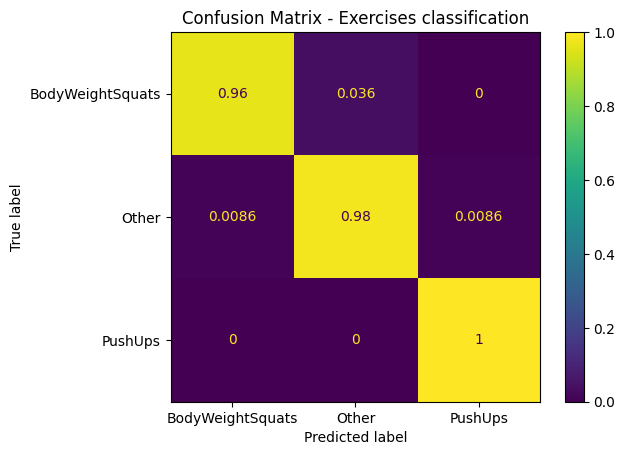

Accuracy: 0.99%
--------------------------------------------------
Classification report:
                  precision    recall  f1-score   support

BodyWeightSquats       0.99      0.98      0.98       100
           Other       0.99      0.99      0.99       170
         PushUps       0.99      1.00      0.99        81

        accuracy                           0.99       351
       macro avg       0.99      0.99      0.99       351
    weighted avg       0.99      0.99      0.99       351

--------------------------------------------------


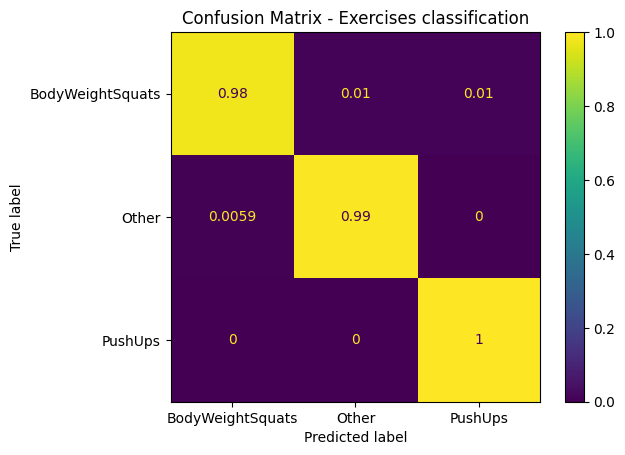

Accuracy: 0.96%
--------------------------------------------------
Classification report:
                  precision    recall  f1-score   support

BodyWeightSquats       0.95      0.87      0.91        84
           Other       0.94      0.98      0.96       192
         PushUps       1.00      1.00      1.00        75

        accuracy                           0.96       351
       macro avg       0.96      0.95      0.96       351
    weighted avg       0.96      0.96      0.96       351

--------------------------------------------------


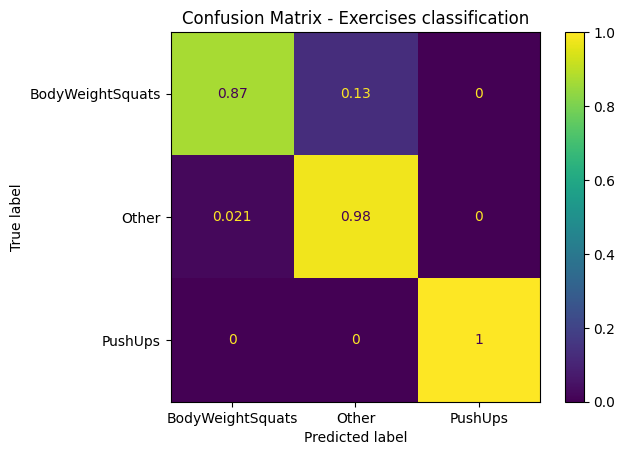

Accuracy: 0.95%
--------------------------------------------------
Classification report:
                  precision    recall  f1-score   support

BodyWeightSquats       1.00      0.80      0.89        80
           Other       0.94      1.00      0.96       233
         PushUps       0.97      1.00      0.99        38

        accuracy                           0.95       351
       macro avg       0.97      0.93      0.95       351
    weighted avg       0.95      0.95      0.95       351

--------------------------------------------------


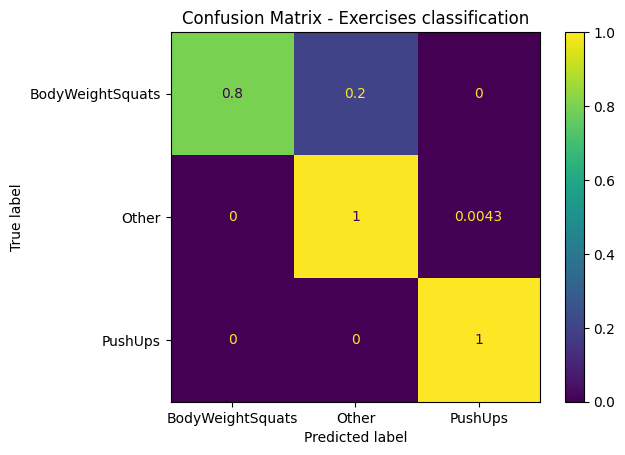

Accuracy: 0.90%
--------------------------------------------------
Classification report:
                  precision    recall  f1-score   support

BodyWeightSquats       0.92      0.78      0.84       124
           Other       0.83      0.94      0.88       139
         PushUps       1.00      1.00      1.00        88

        accuracy                           0.90       351
       macro avg       0.91      0.91      0.91       351
    weighted avg       0.90      0.90      0.90       351

--------------------------------------------------


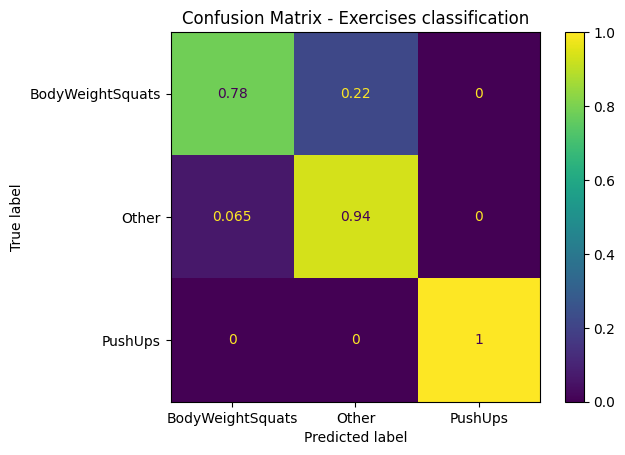

---- END VALIDATION ----


In [4]:
X = df_grouped.drop(columns=['subject_id', 'video_id', 'window_id', 'class'])
y = df_grouped['class']
groups = df_grouped['subject_id']
print(f"Unique subjects quantity: {len(groups.unique())}")

gfk = GroupKFold() #5 splits

all_y_test = []
all_y_pred = []

print("---- INICIALIZATING VALIDATION BY SUBJECTS ----")
for train_index, test_index in gfk.split(X, y, groups):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Model training
    model = RandomForestClassifier()
    model.fit(X_train, y_train)

    # Model predictions
    y_pred = model.predict(X_test)

    # Storage y_test and y_pred for outside loop
    all_y_test.append(y_test)
    all_y_pred.append(y_pred)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.2f}%")
    print("-" * 50)
        
    # Classificacion report
    print("Classification report:")
    print(classification_report(y_test, y_pred))
    print("-" * 50)

    ConfusionMatrixDisplay.from_predictions(
        y_test, 
        y_pred, 
        normalize='true'
    )
    plt.title("Confusion Matrix - Exercises classification")
    plt.show()

print("---- END VALIDATION ----")

